In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


CPU_CSV = Path("cpu_results/combined_cpu.csv")
GPU_CSV = Path("gpu_results/final_tesc_aerial_1cb.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


cpu = pd.read_csv(CPU_CSV)
gpu = pd.read_csv(GPU_CSV)


# Keep only the columns needed for latency comparison
cpu_latency = cpu[
    [
        "mcs_index",
        "snr_index",
        "snr_db",
        "mean_us_per_cb",
        "stddev_us_per_cb",
        "min_us_per_cb",
        "max_us_per_cb",
    ]
].copy()

cpu_latency = cpu_latency.rename(
    columns={
        "mean_us_per_cb": "mean_us_per_codeblock",
        "stddev_us_per_cb": "std_us_per_codeblock",
        "min_us_per_cb": "min_us_per_codeblock",
        "max_us_per_cb": "max_us_per_codeblock",
    }
)

cpu_latency["backend"] = "CPU"


gpu_latency = gpu[
    [
        "timing_mode",
        "mcs_index",
        "snr_index",
        "snr_db",
        "mean_us_per_codeblock",
        "std_us_per_codeblock",
        "min_us_per_codeblock",
        "max_us_per_codeblock",
    ]
].copy()

gpu_latency["backend"] = gpu_latency["timing_mode"].map(
    {
        "gpu_decode_only": "GPU decode only",
        "gpu_plus_bus": "GPU + bus",
    }
)

gpu_latency = gpu_latency.dropna(subset=["backend"])


latency = pd.concat(
    [
        cpu_latency[
            [
                "backend",
                "mcs_index",
                "snr_index",
                "snr_db",
                "mean_us_per_codeblock",
                "std_us_per_codeblock",
                "min_us_per_codeblock",
                "max_us_per_codeblock",
            ]
        ],
        gpu_latency[
            [
                "backend",
                "mcs_index",
                "snr_index",
                "snr_db",
                "mean_us_per_codeblock",
                "std_us_per_codeblock",
                "min_us_per_codeblock",
                "max_us_per_codeblock",
            ]
        ],
    ],
    ignore_index=True,
)

latency = latency.sort_values(["mcs_index", "backend", "snr_db"])

latency.head()

,backend,mcs_index,snr_index,snr_db,mean_us_per_codeblock,std_us_per_codeblock,min_us_per_codeblock,max_us_per_codeblock
0,CPU,5,0,0,18.500116,2.111788,17.107478,27.195390
1,CPU,5,1,6,18.400595,2.230115,16.815740,29.227263
2,CPU,5,2,12,18.681165,2.241184,17.156168,29.879232
3,CPU,5,3,18,18.512992,2.227637,16.988846,29.540487
4,CPU,5,4,24,18.745320,2.224483,17.248024,28.759386


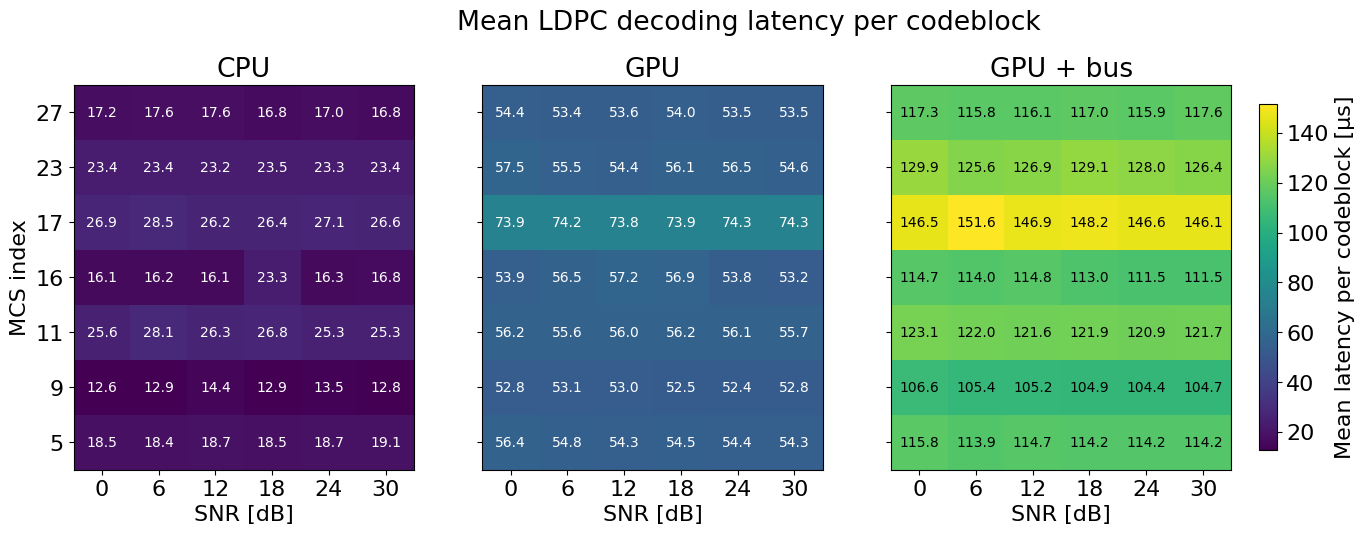

In [15]:
# -----------------------------
# Helper: convert cell centers to cell edges
# -----------------------------

plt.rcParams.update({"font.size": 16})

def centers_to_edges(centers):
    centers = pd.Series(centers, dtype=float).sort_values().to_numpy()

    if len(centers) == 1:
        step = 1.0
        return [centers[0] - step / 2, centers[0] + step / 2]

    midpoints = (centers[:-1] + centers[1:]) / 2

    first_edge = centers[0] - (midpoints[0] - centers[0])
    last_edge = centers[-1] + (centers[-1] - midpoints[-1])

    return [first_edge, *midpoints, last_edge]


# -----------------------------
# Plot side-by-side heatmaps
# -----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True,
)

for ax, platform in zip(axes, platforms):
    data = heatmaps[platform]

    snr_values = data.columns.astype(float)
    mcs_values = data.index.astype(float)

    x_edges = centers_to_edges(snr_values)

    # Keep MCS as categorical rows, but label them with actual MCS indexes
    y_positions = list(range(len(mcs_values)))
    y_edges = [y - 0.5 for y in y_positions] + [y_positions[-1] + 0.5]

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        data.values,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(platform)
    ax.set_xlabel("SNR [dB]")

    ax.set_xticks(snr_values)
    ax.set_xticklabels([f"{x:g}" for x in snr_values])

    ax.set_yticks(y_positions)
    ax.set_yticklabels([f"{int(y)}" for y in mcs_values])

    if platform == "GPU + bus":
        color = "black"
    else:
        color = "white"

    # Print values inside each tile
    for i, mcs in enumerate(mcs_values):
        for j, snr in enumerate(snr_values):
            value = data.iloc[i, j]

            if pd.notna(value):
                ax.text(
                    snr,
                    i,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    c=color,
                    fontsize=10,
                )

axes[0].set_ylabel("MCS index")

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.9,
    pad=0.02,
)

cbar.set_label("Mean latency per codeblock [µs]")

fig.suptitle("Mean LDPC decoding latency per codeblock", y=1.03)

fig.savefig(
    PLOTS_DIR / "heatmap_latency_side_by_side_values.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

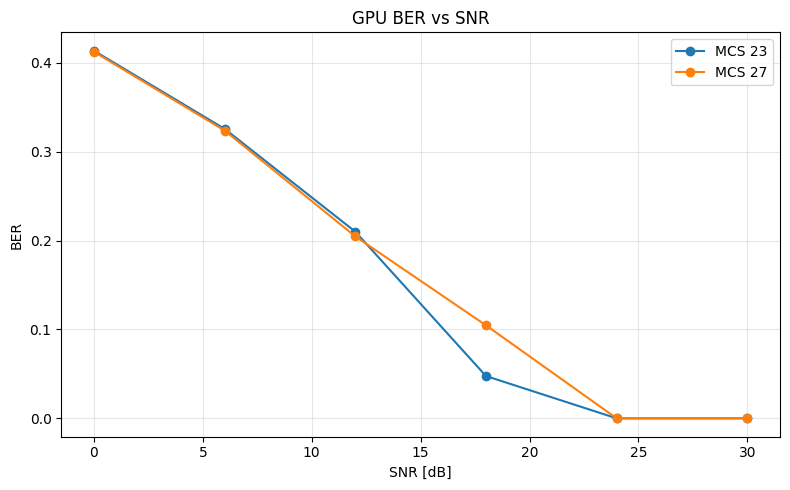

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


GPU_CSV = Path("gpu_results/final_tesc_aerial_1cb.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


gpu = pd.read_csv(GPU_CSV)


# -----------------------------
# Filter GPU decode-only results
# -----------------------------

df = gpu[
    (gpu["timing_mode"] == "gpu_decode_only")
    & (gpu["mcs_index"].isin([23, 27]))
].copy()

df = df.sort_values(["mcs_index", "snr_db"])


# -----------------------------
# Plot BER vs SNR
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for mcs, df_mcs in df.groupby("mcs_index"):
    ax.plot(
        df_mcs["snr_db"],
        df_mcs["aerial_ber"],
        marker="o",
        label=f"MCS {mcs}",
    )

ax.set_title("GPU BER vs SNR")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("BER")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "gpu_ber_vs_snr_mcs_23_27.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

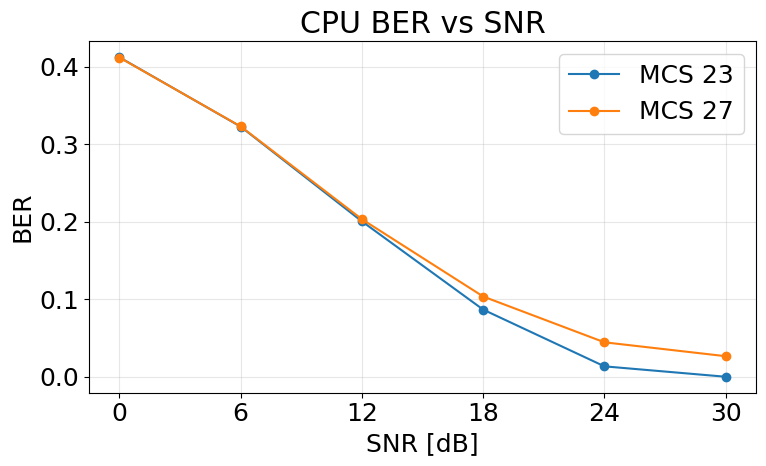

In [9]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 18})

CPU_CSV = Path("cpu_results/combined_cpu.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


cpu = pd.read_csv(CPU_CSV)


# -----------------------------
# Filter CPU results
# -----------------------------

df = cpu[
    cpu["mcs_index"].isin([23, 27])
].copy()

df = df.sort_values(["mcs_index", "snr_db"])


# -----------------------------
# Plot CPU BER vs SNR
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for mcs, df_mcs in df.groupby("mcs_index"):
    ax.plot(
        df_mcs["snr_db"],
        df_mcs["ber"],
        marker="o",
        label=f"MCS {mcs}",
    )

ax.set_title("CPU BER vs SNR")
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("BER")
ax.set_xticks(df_mcs["snr_db"])
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "cpu_ber_vs_snr_mcs_23_27.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

KeyError: '1 CB'

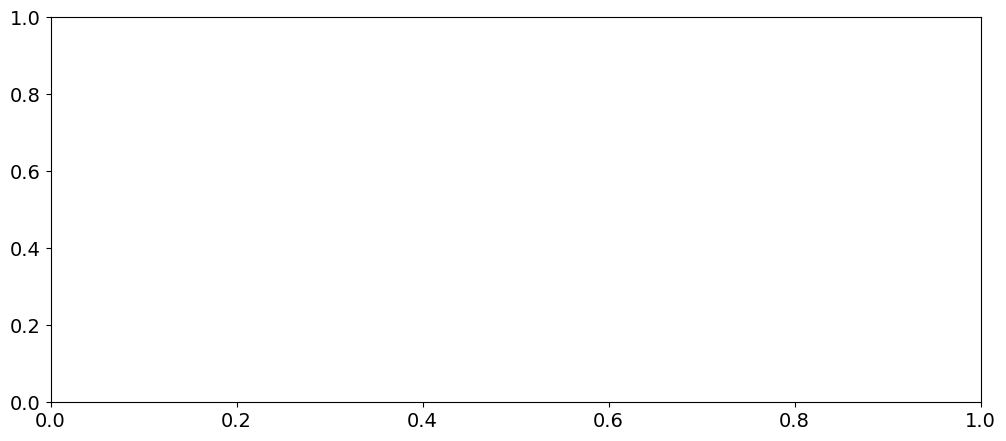

In [23]:
# -----------------------------
# Plot grouped bars with SEM
# -----------------------------

mcs_values = mean_table.index.to_numpy()
x = np.arange(len(mcs_values))

bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))

bars_1cb = ax.bar(
    x - bar_width / 2,
    mean_table["1 CB"],
    width=bar_width,
    yerr=sem_table["1 CB"],
    capsize=4,
    label="1 CB",
)

bars_1024cb = ax.bar(
    x + bar_width / 2,
    mean_table["1024 CBs"],
    width=bar_width,
    yerr=sem_table["1024 CBs"],
    capsize=4,
    label="1024 CBs",
)


def add_bar_labels(ax, bars, errors):
    for bar, err in zip(bars, errors):
        height = bar.get_height()

        if np.isfinite(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + err,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0,
            )


add_bar_labels(ax, bars_1cb, sem_table["1 CB"].to_numpy())
add_bar_labels(ax, bars_1024cb, sem_table["1024 CBs"].to_numpy())

ax.set_title(f"GPU mean latency per codeblock at SNR {target_snr_db} dB")
ax.set_xlabel("MCS index")
ax.set_ylabel("Mean latency per codeblock [µs]")

ax.set_xticks(x)
ax.set_xticklabels(mcs_values)

ax.grid(True, axis="y", alpha=0.3)
ax.legend()

# Add vertical space so labels are not clipped
ymax = max(
    (mean_table["1 CB"] + sem_table["1 CB"]).max(),
    (mean_table["1024 CBs"] + sem_table["1024 CBs"]).max(),
)

ax.set_ylim(0, ymax * 1.15)

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "gpu_latency_1cb_vs_1024cb_snr30_bars_sem_labels.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

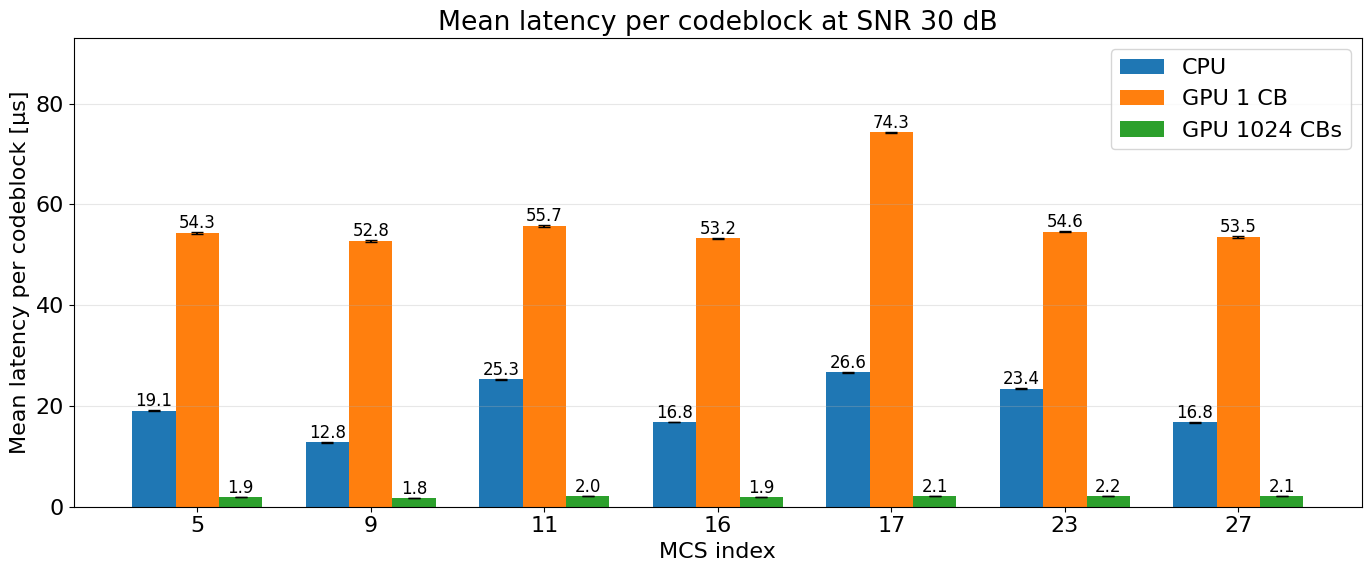

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({"font.size": 16})


CPU_CSV = Path("cpu_results/combined_cpu.csv")
GPU_1CB_CSV = Path("gpu_results/final_tesc_aerial_1cb.csv")
GPU_1024CB_CSV = Path("gpu_results/final_tesc_aerial_1024cb.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


target_snr_db = 30
gpu_timing_mode = "gpu_decode_only"


# -----------------------------
# Load CPU latency
# -----------------------------

def load_cpu_latency(csv_path, label):
    df = pd.read_csv(csv_path)

    df["snr_db"] = pd.to_numeric(df["snr_db"])
    df["mcs_index"] = pd.to_numeric(df["mcs_index"])
    df["mean_us_per_cb"] = pd.to_numeric(df["mean_us_per_cb"])
    df["stddev_us_per_cb"] = pd.to_numeric(df["stddev_us_per_cb"])
    df["repeats"] = pd.to_numeric(df["repeats"])

    df = df[
        np.isclose(df["snr_db"], target_snr_db)
    ].copy()

    df["experiment"] = label
    df["mean_us_per_codeblock"] = df["mean_us_per_cb"]
    df["sem_us_per_codeblock"] = df["stddev_us_per_cb"] / np.sqrt(df["repeats"])

    return df[
        [
            "experiment",
            "mcs_index",
            "snr_db",
            "mean_us_per_codeblock",
            "sem_us_per_codeblock",
        ]
    ]


# -----------------------------
# Load GPU latency
# -----------------------------

def load_gpu_latency(csv_path, label):
    df = pd.read_csv(csv_path)

    df["snr_db"] = pd.to_numeric(df["snr_db"])
    df["mcs_index"] = pd.to_numeric(df["mcs_index"])
    df["mean_us_per_codeblock"] = pd.to_numeric(df["mean_us_per_codeblock"])
    df["std_us_per_codeblock"] = pd.to_numeric(df["std_us_per_codeblock"])
    df["measured_repeats"] = pd.to_numeric(df["measured_repeats"])

    df = df[
        (df["timing_mode"] == gpu_timing_mode)
        & np.isclose(df["snr_db"], target_snr_db)
    ].copy()

    df["experiment"] = label
    df["sem_us_per_codeblock"] = (
        df["std_us_per_codeblock"] / np.sqrt(df["measured_repeats"])
    )

    return df[
        [
            "experiment",
            "mcs_index",
            "snr_db",
            "mean_us_per_codeblock",
            "sem_us_per_codeblock",
        ]
    ]


cpu_latency = load_cpu_latency(CPU_CSV, "CPU")
gpu_1cb = load_gpu_latency(GPU_1CB_CSV, "GPU 1 CB")
gpu_1024cb = load_gpu_latency(GPU_1024CB_CSV, "GPU 1024 CBs")


df = pd.concat(
    [
        cpu_latency,
        gpu_1cb,
        gpu_1024cb,
    ],
    ignore_index=True,
)

df = df.sort_values(["mcs_index", "experiment"])


# -----------------------------
# Pivot for grouped bars
# -----------------------------

experiment_order = ["CPU", "GPU 1 CB", "GPU 1024 CBs"]

mean_table = df.pivot_table(
    index="mcs_index",
    columns="experiment",
    values="mean_us_per_codeblock",
    aggfunc="mean",
).sort_index()

sem_table = df.pivot_table(
    index="mcs_index",
    columns="experiment",
    values="sem_us_per_codeblock",
    aggfunc="mean",
).sort_index()

mean_table = mean_table[experiment_order]
sem_table = sem_table[experiment_order]


# -----------------------------
# Plot grouped bars with SEM
# -----------------------------

mcs_values = mean_table.index.to_numpy()
x = np.arange(len(mcs_values))

bar_width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars_cpu = ax.bar(
    x - bar_width,
    mean_table["CPU"],
    width=bar_width,
    yerr=sem_table["CPU"],
    capsize=4,
    label="CPU",
)

bars_gpu_1cb = ax.bar(
    x,
    mean_table["GPU 1 CB"],
    width=bar_width,
    yerr=sem_table["GPU 1 CB"],
    capsize=4,
    label="GPU 1 CB",
)

bars_gpu_1024cb = ax.bar(
    x + bar_width,
    mean_table["GPU 1024 CBs"],
    width=bar_width,
    yerr=sem_table["GPU 1024 CBs"],
    capsize=4,
    label="GPU 1024 CBs",
)


# -----------------------------
# Print mean latency above bars
# -----------------------------

def add_bar_labels(ax, bars, errors):
    for bar, err in zip(bars, errors):
        height = bar.get_height()

        if np.isfinite(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + err,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=12,
                rotation=0,
            )


add_bar_labels(ax, bars_cpu, sem_table["CPU"].to_numpy())
add_bar_labels(ax, bars_gpu_1cb, sem_table["GPU 1 CB"].to_numpy())
add_bar_labels(ax, bars_gpu_1024cb, sem_table["GPU 1024 CBs"].to_numpy())


# -----------------------------
# Formatting
# -----------------------------

ax.set_title(f"Mean latency per codeblock at SNR {target_snr_db} dB")
ax.set_xlabel("MCS index")
ax.set_ylabel("Mean latency per codeblock [µs]")

ax.set_xticks(x)
ax.set_xticklabels(mcs_values)

ax.grid(True, axis="y", alpha=0.3)
ax.legend()

ymax = max(
    (mean_table[col] + sem_table[col]).max()
    for col in experiment_order
)

ax.set_ylim(0, ymax * 1.25)

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "latency_cpu_gpu1cb_gpu1024cb_snr30_bars_sem_labels.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

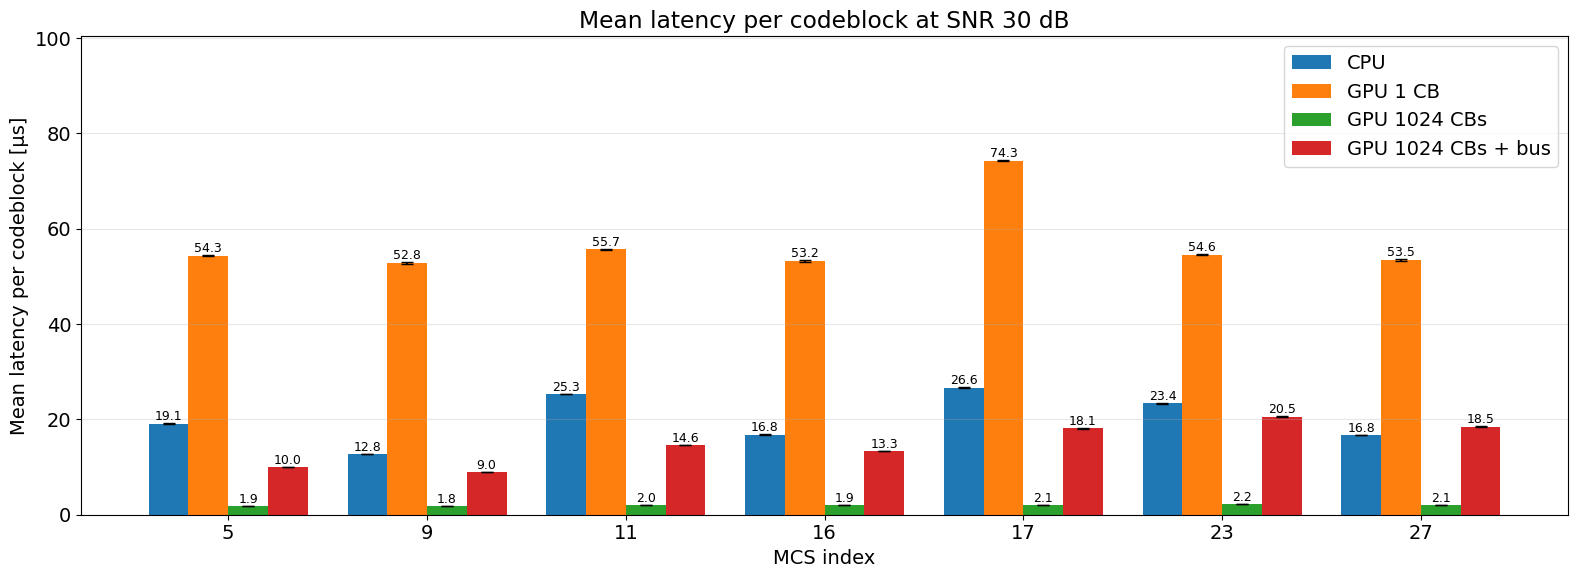

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({"font.size": 14})


CPU_CSV = Path("cpu_results/combined_cpu.csv")
GPU_1CB_CSV = Path("gpu_results/final_tesc_aerial_1cb.csv")
GPU_1024CB_CSV = Path("gpu_results/final_tesc_aerial_1024cb.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


target_snr_db = 30


# -----------------------------
# Load CPU latency
# -----------------------------

def load_cpu_latency(csv_path, label):
    df = pd.read_csv(csv_path)

    df["snr_db"] = pd.to_numeric(df["snr_db"])
    df["mcs_index"] = pd.to_numeric(df["mcs_index"])
    df["mean_us_per_cb"] = pd.to_numeric(df["mean_us_per_cb"])
    df["stddev_us_per_cb"] = pd.to_numeric(df["stddev_us_per_cb"])
    df["repeats"] = pd.to_numeric(df["repeats"])

    df = df[np.isclose(df["snr_db"], target_snr_db)].copy()

    df["experiment"] = label
    df["mean_us_per_codeblock"] = df["mean_us_per_cb"]
    df["sem_us_per_codeblock"] = df["stddev_us_per_cb"] / np.sqrt(df["repeats"])

    return df[
        [
            "experiment",
            "mcs_index",
            "snr_db",
            "mean_us_per_codeblock",
            "sem_us_per_codeblock",
        ]
    ]


# -----------------------------
# Load GPU latency
# -----------------------------

def load_gpu_latency(csv_path, label, timing_mode):
    df = pd.read_csv(csv_path)

    df["snr_db"] = pd.to_numeric(df["snr_db"])
    df["mcs_index"] = pd.to_numeric(df["mcs_index"])
    df["mean_us_per_codeblock"] = pd.to_numeric(df["mean_us_per_codeblock"])
    df["std_us_per_codeblock"] = pd.to_numeric(df["std_us_per_codeblock"])
    df["measured_repeats"] = pd.to_numeric(df["measured_repeats"])

    df = df[
        (df["timing_mode"] == timing_mode)
        & np.isclose(df["snr_db"], target_snr_db)
    ].copy()

    df["experiment"] = label
    df["sem_us_per_codeblock"] = (
        df["std_us_per_codeblock"] / np.sqrt(df["measured_repeats"])
    )

    return df[
        [
            "experiment",
            "mcs_index",
            "snr_db",
            "mean_us_per_codeblock",
            "sem_us_per_codeblock",
        ]
    ]


cpu_latency = load_cpu_latency(CPU_CSV, "CPU")

gpu_1cb = load_gpu_latency(
    GPU_1CB_CSV,
    "GPU 1 CB",
    "gpu_decode_only",
)

gpu_1024cb = load_gpu_latency(
    GPU_1024CB_CSV,
    "GPU 1024 CBs",
    "gpu_decode_only",
)

gpu_1024cb_bus = load_gpu_latency(
    GPU_1024CB_CSV,
    "GPU 1024 CBs + bus",
    "gpu_plus_bus",
)


df = pd.concat(
    [
        cpu_latency,
        gpu_1cb,
        gpu_1024cb,
        gpu_1024cb_bus,
    ],
    ignore_index=True,
)

df = df.sort_values(["mcs_index", "experiment"])


# -----------------------------
# Pivot for grouped bars
# -----------------------------

experiment_order = [
    "CPU",
    "GPU 1 CB",
    "GPU 1024 CBs",
    "GPU 1024 CBs + bus",
]

mean_table = df.pivot_table(
    index="mcs_index",
    columns="experiment",
    values="mean_us_per_codeblock",
    aggfunc="mean",
).sort_index()

sem_table = df.pivot_table(
    index="mcs_index",
    columns="experiment",
    values="sem_us_per_codeblock",
    aggfunc="mean",
).sort_index()

mean_table = mean_table.reindex(columns=experiment_order)
sem_table = sem_table.reindex(columns=experiment_order)


# -----------------------------
# Plot grouped bars with SEM
# -----------------------------

mcs_values = mean_table.index.to_numpy()
x = np.arange(len(mcs_values))

bar_width = 0.20

fig, ax = plt.subplots(figsize=(16, 6))

bars_cpu = ax.bar(
    x - 1.5 * bar_width,
    mean_table["CPU"],
    width=bar_width,
    yerr=sem_table["CPU"],
    capsize=4,
    label="CPU",
)

bars_gpu_1cb = ax.bar(
    x - 0.5 * bar_width,
    mean_table["GPU 1 CB"],
    width=bar_width,
    yerr=sem_table["GPU 1 CB"],
    capsize=4,
    label="GPU 1 CB",
)

bars_gpu_1024cb = ax.bar(
    x + 0.5 * bar_width,
    mean_table["GPU 1024 CBs"],
    width=bar_width,
    yerr=sem_table["GPU 1024 CBs"],
    capsize=4,
    label="GPU 1024 CBs",
)

bars_gpu_1024cb_bus = ax.bar(
    x + 1.5 * bar_width,
    mean_table["GPU 1024 CBs + bus"],
    width=bar_width,
    yerr=sem_table["GPU 1024 CBs + bus"],
    capsize=4,
    label="GPU 1024 CBs + bus",
)


# -----------------------------
# Print mean latency above bars
# -----------------------------

def add_bar_labels(ax, bars, errors):
    for bar, err in zip(bars, errors):
        height = bar.get_height()

        if np.isfinite(height):
            if not np.isfinite(err):
                err = 0

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + err,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0,
            )


add_bar_labels(ax, bars_cpu, sem_table["CPU"].to_numpy())
add_bar_labels(ax, bars_gpu_1cb, sem_table["GPU 1 CB"].to_numpy())
add_bar_labels(ax, bars_gpu_1024cb, sem_table["GPU 1024 CBs"].to_numpy())
add_bar_labels(ax, bars_gpu_1024cb_bus, sem_table["GPU 1024 CBs + bus"].to_numpy())


# -----------------------------
# Formatting
# -----------------------------

ax.set_title(f"Mean latency per codeblock at SNR {target_snr_db} dB")
ax.set_xlabel("MCS index")
ax.set_ylabel("Mean latency per codeblock [µs]")

ax.set_xticks(x)
ax.set_xticklabels(mcs_values)

ax.grid(True, axis="y", alpha=0.3)
ax.legend()

ymax = max(
    (mean_table[col] + sem_table[col]).max()
    for col in experiment_order
)

ax.set_ylim(0, ymax * 1.35)

fig.tight_layout()

fig.savefig(
    PLOTS_DIR / "latency_cpu_gpu1cb_gpu1024cb_gpu1024cb_bus_snr30_bars_sem_labels.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()